In [32]:
import os
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import json
import pandas as pd
from collections import Counter
from scipy.stats import gaussian_kde
from copy import deepcopy
import constants
from constants import meta_data_dir, blues, reds, output_dir, font_prop

# External data

In [4]:
data_dir = "/Users/zhoukuangqi/Desktop/pepbenchmark/0919_new"

colors = {
    "pos": reds[3],
    "neg": blues[2],
}
edge_colors = {
    "pos": reds[-2],
    "neg": blues[-2],
}
legends = {
    "pos": "positive",
    "neg": "negtive",
}

In [2]:
os.makedirs(save_dir := (output_dir / Path("new3_0919_len")), exist_ok=True)

In [23]:
def get_prop(prop_name, row):
    if prop_name == "seq_len":
        return len(row["sequence"].strip())
    elif prop_name == 'iso':
        return row['isoelectric_point']
    else:
        raise ValueError
    
x_axis_names = {
    'seq_len': "Sequence Length",
    'hydro': "Hydrophilicity",
    'charge': "Charge",
    "iso": "isoelectric_point",
}

prop_names = {
    "AMP_PepDiffusion": ["iso", ],
    "nonfouling_pepbert": ["seq_len"],
    "ttca_apml": ["seq_len"],
}

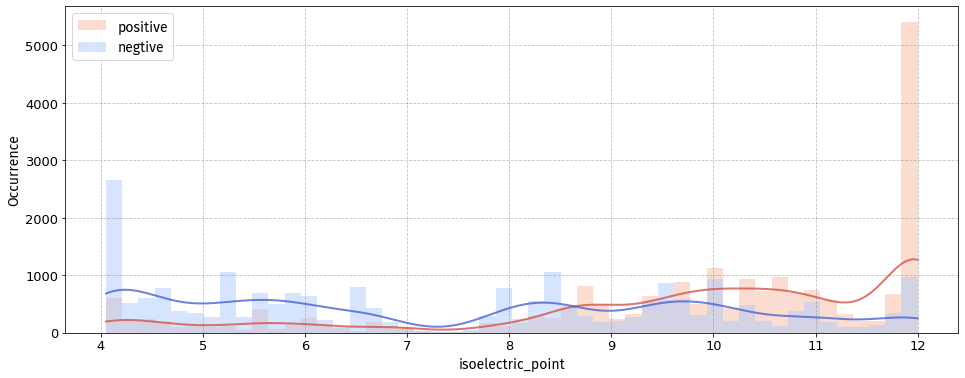

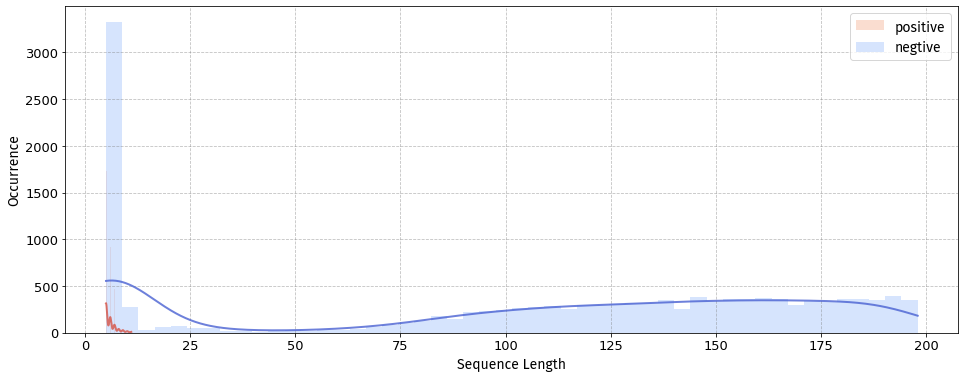

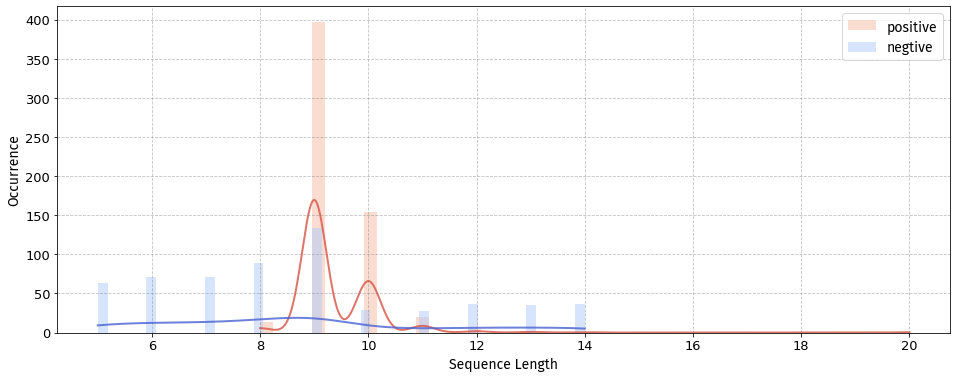

In [30]:
for dataset_name in [
    "AMP_PepDiffusion",
    "nonfouling_pepbert",
    "ttca_apml",
]:
    props = {prop_name: {"pos": [], "neg": []} for prop_name in prop_names[dataset_name]}
    data_info = pd.read_csv(
        data_dir / Path(f"{dataset_name}.csv")
    )
    
    for _, row in data_info.iterrows():
        for prop_name in prop_names[dataset_name]:
            (props[prop_name]["pos"] if row["label"] else props[prop_name]["neg"]).append(
                get_prop(prop_name, row)
            )
    
    fig, axe = plt.subplots(1, 1, figsize=(16, 6))
    for i, prop_name in enumerate(prop_names[dataset_name]):
        for label in ['pos', 'neg']:
            prop_values = np.asarray(props[prop_name][label])
            p_prop = gaussian_kde(prop_values)

            counts, bins, _ = axe.hist(
                prop_values, 
                bins=50, 
                alpha=0.5, 
                color=colors[label],
                density=False,
                label=legends[label],
            )
            legend_font_prop = deepcopy(font_prop)
            legend_font_prop.set_size(14)
            axe.legend(fontsize=20, prop=legend_font_prop)
            
            bin_width = bins[1] - bins[0]
            y_min, y_max = prop_values.min(), prop_values.max()
            x = np.linspace(y_min, y_max, 500)
            y = p_prop(x) * len(prop_values) * bin_width

            axe.plot(
                x,
                y,
                color=edge_colors[label],
                linewidth=2,
                alpha=0.8,
            )

        axe.set_xlabel(x_axis_names[prop_name], fontsize=14, fontproperties=font_prop)
        if i == 0:
            axe.set_ylabel("Occurrence", fontsize=14, fontproperties=font_prop)
        axe.tick_params(axis='x', labelsize=13)
        axe.tick_params(axis='y', labelsize=13)
        axe.grid(True, linestyle='--', color='gray', alpha=0.5)
    plt.savefig(
        save_dir / Path(f"{dataset_name}.png"),
        dpi=200,
        bbox_inches="tight",
        transparent=True,
    )

# Our data

In [33]:
data_dir = constants.data_dir
prop_names = {
    "antimicrobial": ["iso"], 
}

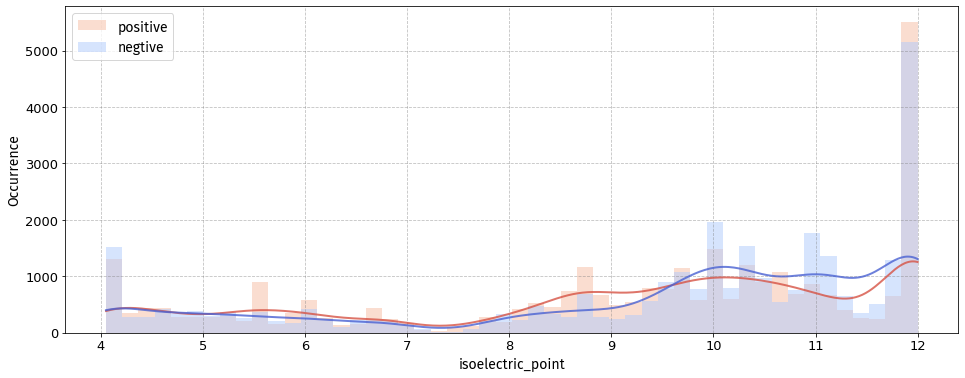

In [35]:
for dataset_name in ["antimicrobial"]:
    props = {prop_name: {"pos": [], "neg": []} for prop_name in prop_names[dataset_name]}
    data_info = pd.read_csv(
        data_dir / Path(dataset_name) / Path("enhanced_data.csv")
    )
    
    for _, row in data_info.iterrows():
        for prop_name in prop_names[dataset_name]:
            (props[prop_name]["pos"] if row["label"] else props[prop_name]["neg"]).append(
                get_prop(prop_name, row)
            )
    
    fig, axe = plt.subplots(1, 1, figsize=(16, 6))
    for i, prop_name in enumerate(prop_names[dataset_name]):
        for label in ['pos', 'neg']:
            prop_values = np.asarray(props[prop_name][label])
            p_prop = gaussian_kde(prop_values)

            counts, bins, _ = axe.hist(
                prop_values, 
                bins=50, 
                alpha=0.5, 
                color=colors[label],
                density=False,
                label=legends[label],
            )
            legend_font_prop = deepcopy(font_prop)
            legend_font_prop.set_size(14)
            axe.legend(fontsize=20, prop=legend_font_prop)
            
            bin_width = bins[1] - bins[0]
            y_min, y_max = prop_values.min(), prop_values.max()
            x = np.linspace(y_min, y_max, 500)
            y = p_prop(x) * len(prop_values) * bin_width

            axe.plot(
                x,
                y,
                color=edge_colors[label],
                linewidth=2,
                alpha=0.8,
            )

        axe.set_xlabel(x_axis_names[prop_name], fontsize=14, fontproperties=font_prop)
        if i == 0:
            axe.set_ylabel("Occurrence", fontsize=14, fontproperties=font_prop)
        axe.tick_params(axis='x', labelsize=13)
        axe.tick_params(axis='y', labelsize=13)
        axe.grid(True, linestyle='--', color='gray', alpha=0.5)
    plt.savefig(
        save_dir / Path(f"{dataset_name}.png"),
        dpi=200,
        bbox_inches="tight",
        transparent=True,
    )